# Vertebra-Reorder Diagnostic (Fix A — post-processing)

**Question**: How much of the v4-family Dice gap is class-confusion (the model knows where the spine is, but swaps adjacent vertebra labels) vs true mis-segmentation (wrong spine boundary)? And does fixing the class-confusion at post-process time change the Cobb-from-seg estimates?

**Method**: For each v4-family checkpoint, run inference on the val set, then apply a vertebra-reorder algorithm: find connected components in the predicted seg, re-label them by y-centroid (T1 = topmost component → L5 = bottommost), drop duplicate-class components keeping the largest. Compare dice and `cobb_from_seg` before vs after.

**No retraining.** Pure post-processing diagnostic. Per [[Easy_Wins_Backlog]] T1.4 + the user's observation that pred_seg in the qualitative panels of v4 / v4_tierA / v4_chain shows color-mixed vertebra labels even when the spine SHAPE is correct.

**Decision tree** (after the run):
- Reorder closes ≥0.05 dice on most checkpoints → class-confusion is the dominant gap; commit to Fix B (training-time ordering loss, [[Open_Questions]] Q-20).
- Reorder closes 0.01–0.05 → modest improvement; reorder becomes a default inference step but Fix B is lower-priority.
- Reorder closes <0.01 → class confusion is NOT the gap; the model has deeper segmentation issues; deprioritize Q-20 and pivot to architectural rethink (Fix C).

Output: comparative table across all v4-family runs, filed as `[[2026-05-XX_vertebra_reorder_diagnostic]]`.


## 0 · Setup


In [15]:
import json
import sys
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from scipy import ndimage
from torch.utils.data import DataLoader, Dataset
from torchvision import models

import warnings
warnings.filterwarnings("ignore", message=".*lerp.*")


In [16]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")


repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [17]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.dataset import IMG_H, IMG_W, TARGET_IDS_V2, preprocess_case

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}")


size=512x256  seg_classes=18  vertebrae=17


In [18]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def trainable_rows(df, min_vertebrae=14):
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df, val_frac=0.2, seed=SEED):
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN = pd.read_csv(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
print(f"trainable={len(TRAINABLE)}  train={len(TRAIN_DF)}  val={len(VAL_DF)}")


trainable=249  train=199  val=50


## 1 · Architecture (copied from v4 — same for all checkpoints in this diagnostic)

All v4-family checkpoints share the same `MultiTaskEncoderUNet` architecture (in_ch=1, ResNet-34 backbone, 18-class seg head). Loading code is identical across runs — only the state dict changes.


In [19]:
def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )

class _Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        dy, dx = skip.shape[2] - x.shape[2], skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([x, skip], dim=1))

TOTAL_KEYPOINTS = 68  # v4 default

class MultiTaskEncoderUNet(nn.Module):
    def __init__(self, in_ch=1, num_seg_classes=NUM_SEG_CLASSES, num_keypoints=TOTAL_KEYPOINTS,
                 pretrained=False, dropout=0.2, cobb_norm=90.0):
        super().__init__()
        self.cobb_norm = cobb_norm
        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = backbone.conv1.weight.data.mean(dim=1, keepdim=True)
        self.bn1 = backbone.bn1; self.relu = backbone.relu; self.maxpool = backbone.maxpool
        self.layer1, self.layer2, self.layer3, self.layer4 = backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        self.up1 = _Up(512, 256, 256); self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64);   self.up4 = _Up(64, 64, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(128, 1),
        )
    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x))); x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool); s2 = self.layer2(s1); s3 = self.layer3(s2)
        bridge = self.layer4(s3)
        y = self.up1(bridge, s3); y = self.up2(y, s2)
        y_q = self.up3(y, s1); y = self.up4(y_q, x0); y_full = self.final_up(y); y_full = self.drop(y_full)
        return {
            "seg": self.seg_head(y_full),
            "kpt": self.kpt_head(y_q),
            "cobb": (self.cobb_head(bridge).squeeze(-1)) * self.cobb_norm,
        }


## 2 · Vertebra-Reorder Algorithm (Fix A)

Per [[Easy_Wins_Backlog]] T1.4. Procedure:

1. For each non-background class `c ∈ 1..17`, find connected components of pixels predicted as class `c`.
2. Aggregate ALL components (across all classes) into a single list, each tagged with its y-centroid and area.
3. Drop tiny components (area < `MIN_COMPONENT_PX`) as noise.
4. Sort components by y-centroid (top-to-bottom).
5. Re-label them sequentially: top component → class 1 (T1), next → class 2 (T2), …, last → class up to 17 (L5).
6. If more than 17 components survive, drop the smallest-area extras.

**Behavior on edge cases**:
- Model predicts 17 cleanly-separated components → reorder gives a perfect T1→L5 sequence (only fixes class-confusion swaps).
- Model predicts <17 components → reorder labels them T1..T_n (missing the bottom vertebrae). This may HURT dice for true L4/L5 if the model just missed them entirely.
- Model predicts >17 components → drop smallest extras. May hurt dice if a real vertebra got fragmented.

**Limitation**: this is purely post-hoc. Doesn't help the encoder learn the correct ordering — see Q-20 for the training-time fix.


In [20]:
MIN_COMPONENT_PX = 30  # drop noisier-than-this components as predicted noise

def reorder_vertebrae(
    pred_seg: np.ndarray,
    num_classes: int = NUM_SEG_CLASSES,
    min_component_px: int = MIN_COMPONENT_PX,
) -> np.ndarray:
    """Re-label vertebra connected components in y-centroid order (T1 top → L5 bottom).

    Args:
        pred_seg: (H, W) int array, 0=bg, 1..num_classes-1 = vertebra classes
        num_classes: total seg classes (background + 17 vertebrae = 18)
        min_component_px: drop components smaller than this many pixels (noise threshold)
    Returns:
        out_seg: (H, W) int array with vertebrae re-labeled top-to-bottom 1..min(N, num_classes-1)
    """
    out = np.zeros_like(pred_seg)
    components = []  # (y_centroid, area, component_mask)

    for c in range(1, num_classes):
        mask = (pred_seg == c)
        if not mask.any():
            continue
        labeled, n = ndimage.label(mask)
        for k in range(1, n + 1):
            comp = (labeled == k)
            area = comp.sum()
            if area < min_component_px:
                continue
            ys, _xs = np.where(comp)
            components.append((float(ys.mean()), int(area), comp))

    # sort by y-centroid (top to bottom). If too many, drop smallest extras.
    components.sort(key=lambda x: x[0])
    max_vert = num_classes - 1
    if len(components) > max_vert:
        # drop the smallest extras until we're at max_vert
        sorted_by_area = sorted(components, key=lambda x: x[1], reverse=True)[:max_vert]
        kept_set = {id(c[2]) for c in sorted_by_area}
        components = [c for c in components if id(c[2]) in kept_set]
        # re-sort by y after dropping
        components.sort(key=lambda x: x[0])

    for i, (_, _, comp) in enumerate(components, start=1):
        out[comp] = i
    return out


# sanity check on a GT mask: reorder should be a no-op (or near-no-op)
from ai.preprocessing.segmentation import remap_to_target_classes
from ai.training.dataset import read_mask, resize_mask
_sample = TRAINABLE.iloc[0]
_mask = remap_to_target_classes(
    resize_mask(read_mask(Path(_sample['multiclass_mask_path'])), IMG_H, IMG_W),
    target_ids=TARGET_IDS_V2,
)
_reordered = reorder_vertebrae(_mask)
n_classes_before = len([c for c in range(1, NUM_SEG_CLASSES) if (_mask == c).any()])
n_classes_after  = len([c for c in range(1, NUM_SEG_CLASSES) if (_reordered == c).any()])
agree = float((_mask == _reordered).mean())
print(f"GT mask sanity: classes_before={n_classes_before}, classes_after={n_classes_after}, pixel_agreement={agree:.3f}")
print("Should be ~1.0 (GT is already correctly ordered T1->L5).")


GT mask sanity: classes_before=17, classes_after=17, pixel_agreement=1.000
Should be ~1.0 (GT is already correctly ordered T1->L5).


## 3 · Inference + Dice Helpers


In [21]:
def per_class_dice(pred: np.ndarray, gt: np.ndarray, num_classes: int = NUM_SEG_CLASSES) -> dict:
    """Mean dice over present GT classes (matches v4 evaluate_case)."""
    scores = []
    per_class = {}
    for c in range(1, num_classes):
        p, g = (pred == c), (gt == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            d = float(2.0 * (p & g).sum() / denom)
            per_class[c] = d
            if g.any():  # only count if GT had this class (consistent with v4)
                scores.append(d)
    return {"mean": float(np.mean(scores)) if scores else float("nan"), "per_class": per_class}


@torch.no_grad()
def evaluate_checkpoint_with_reorder(model: nn.Module, val_df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Run inference on val, compute dice + cobb_from_seg before and after reorder."""
    rows = []
    for _, row in val_df.iterrows():
        case = preprocess_case(row)
        out = model(case["image"].unsqueeze(0).to(DEVICE))
        seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu().numpy()
        seg_gt = case["seg"].numpy()

        seg_reord = reorder_vertebrae(seg_pred)

        dice_pre  = per_class_dice(seg_pred,  seg_gt)
        dice_post = per_class_dice(seg_reord, seg_gt)
        cobb_pre  = float(cobb_from_segmentation_tangent(seg_pred))
        cobb_post = float(cobb_from_segmentation_tangent(seg_reord))
        cobb_gt = row.get("cobb_angle_deg")
        cobb_gt = float(cobb_gt) if pd.notna(cobb_gt) else float("nan")

        n_components = len([c for c in range(1, NUM_SEG_CLASSES) if (seg_pred == c).any()])

        rows.append({
            "checkpoint": name,
            "image": Path(row["image_path"]).stem,
            "dice_pre":   dice_pre["mean"],
            "dice_post":  dice_post["mean"],
            "dice_delta": dice_post["mean"] - dice_pre["mean"],
            "cobb_seg_pre":  cobb_pre,
            "cobb_seg_post": cobb_post,
            "cobb_gt":   cobb_gt,
            "cobb_seg_pre_err":  abs(cobb_pre  - cobb_gt) if np.isfinite(cobb_gt) else float("nan"),
            "cobb_seg_post_err": abs(cobb_post - cobb_gt) if np.isfinite(cobb_gt) else float("nan"),
            "n_components_pred": n_components,
        })
    return pd.DataFrame(rows)


## 4 · Checkpoints to Evaluate

Five v4-family checkpoints (and v3_corrected as predecessor reference). For checkpoints with both `model.pt` (best-dice) and `model_best_cobb.pt`, evaluate **both** so we can see if reorder behaves differently at the two regimes.


In [22]:
CHECKPOINT_DIRS = {
    "v4 Kendall (best-dice)":             "multitask_v4/20260502T1325_5fc5718a/model.pt",
    "v4 Kendall (best-cobb)":             "multitask_v4/20260502T1325_5fc5718a/model_best_cobb.pt",
    "v4-fixedweight (best-dice)":         "multitask_v4_fixedweight/20260502T2140_29a59336/model.pt",
    "v4-fixedweight (best-cobb)":         "multitask_v4_fixedweight/20260502T2140_29a59336/model_best_cobb.pt",
    "v4 + tierA (best-dice)":             "multitask_v4_tierA/20260503T1300_f18bff7b/model.pt",
    "v4 + naive chain (best-dice)":       "multitask_v4_chain/20260503T1435_2c076ccd/model.pt",
    "v4 + naive chain (best-cobb)":       "multitask_v4_chain/20260503T1435_2c076ccd/model_best_cobb.pt",
    "v5 cobb-warmup (best-dice)":         "multitask_v5_cobb_warmup/20260502T2302_7f8bb14c/model.pt",
    "v6 both-ramp (best-dice)":           "multitask_v6_both_ramp/20260503T0104_ed30acce/model.pt",
    "v7 asym-ramp (best-dice)":           "multitask_v7_asym_ramp/20260503T0226_9c686f3a/model.pt",
}

CKPT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints"

# verify all exist before launching the loop
for name, rel in CHECKPOINT_DIRS.items():
    p = CKPT_ROOT / rel
    print(f"  {'OK ' if p.exists() else 'MISS'}  {name:35s}  {rel}")


  OK   v4 Kendall (best-dice)               multitask_v4/20260502T1325_5fc5718a/model.pt
  OK   v4 Kendall (best-cobb)               multitask_v4/20260502T1325_5fc5718a/model_best_cobb.pt
  OK   v4-fixedweight (best-dice)           multitask_v4_fixedweight/20260502T2140_29a59336/model.pt
  OK   v4-fixedweight (best-cobb)           multitask_v4_fixedweight/20260502T2140_29a59336/model_best_cobb.pt
  OK   v4 + tierA (best-dice)               multitask_v4_tierA/20260503T1300_f18bff7b/model.pt
  OK   v4 + naive chain (best-dice)         multitask_v4_chain/20260503T1435_2c076ccd/model.pt
  OK   v4 + naive chain (best-cobb)         multitask_v4_chain/20260503T1435_2c076ccd/model_best_cobb.pt
  OK   v5 cobb-warmup (best-dice)           multitask_v5_cobb_warmup/20260502T2302_7f8bb14c/model.pt
  OK   v6 both-ramp (best-dice)             multitask_v6_both_ramp/20260503T0104_ed30acce/model.pt
  OK   v7 asym-ramp (best-dice)             multitask_v7_asym_ramp/20260503T0226_9c686f3a/model.pt


## 5 · Run Inference + Reorder on All Checkpoints

Per-checkpoint: load state dict, evaluate val set, store per-image deltas. Skips checkpoints that don't exist.


In [23]:
all_results = []
model_template = MultiTaskEncoderUNet(pretrained=False, dropout=0.2).to(DEVICE)
for name, rel in CHECKPOINT_DIRS.items():
    p = CKPT_ROOT / rel
    if not p.exists():
        print(f"  SKIP {name} (no file)")
        continue
    state = torch.load(p, map_location='cpu')  # DirectML's torch.load doesn't accept torch.device; load to CPU then load_state_dict handles transfer
    sd = state["model"] if isinstance(state, dict) and "model" in state else state
    model_template.load_state_dict(sd)
    model_template.eval()
    df = evaluate_checkpoint_with_reorder(model_template, VAL_DF, name)
    all_results.append(df)
    print(f"  done {name}  (n_val={len(df)})")

ALL = pd.concat(all_results, ignore_index=True)
print(f"\nevaluated {ALL['checkpoint'].nunique()} checkpoints x {len(VAL_DF)} val cases = {len(ALL)} rows")


/tmp/ipykernel_56780/2618528235.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(p, map_location='cpu')  # DirectML's torch.load doesn't accept torch.d

  done v4 Kendall (best-dice)  (n_val=50)
  done v4 Kendall (best-cobb)  (n_val=50)
  done v4-fixedweight (best-dice)  (n_val=50)
  done v4-fixedweight (best-cobb)  (n_val=50)
  done v4 + tierA (best-dice)  (n_val=50)
  done v4 + naive chain (best-dice)  (n_val=50)
  done v4 + naive chain (best-cobb)  (n_val=50)
  done v5 cobb-warmup (best-dice)  (n_val=50)
  done v6 both-ramp (best-dice)  (n_val=50)
  done v7 asym-ramp (best-dice)  (n_val=50)

evaluated 10 checkpoints x 50 val cases = 500 rows


## 6 · Summary — Dice / Cobb Deltas per Checkpoint

Mean per-image dice and `cobb_from_seg` MAE before vs after reorder, plus the median number of predicted components (relative to the target 17). If a checkpoint predicts ~17 components and the delta is positive, class-confusion is real and reorder fixes it. If a checkpoint predicts <<17 or the delta is negative, the model has deeper issues than label-swapping.


In [24]:
summary = (
    ALL.groupby("checkpoint")
       .agg(
           mean_dice_pre=("dice_pre", "mean"),
           mean_dice_post=("dice_post", "mean"),
           mean_dice_delta=("dice_delta", "mean"),
           median_n_components=("n_components_pred", "median"),
           cobb_seg_mae_pre=("cobb_seg_pre_err", "mean"),
           cobb_seg_mae_post=("cobb_seg_post_err", "mean"),
       )
       .round(3)
       .reset_index()
       .sort_values("mean_dice_pre", ascending=False)
)
summary["cobb_seg_mae_delta"] = (summary["cobb_seg_mae_post"] - summary["cobb_seg_mae_pre"]).round(2)
print("Vertebra-reorder diagnostic — comparative table\n")
print(summary.to_string(index=False))


Vertebra-reorder diagnostic — comparative table

                  checkpoint  mean_dice_pre  mean_dice_post  mean_dice_delta  median_n_components  cobb_seg_mae_pre  cobb_seg_mae_post  cobb_seg_mae_delta
  v4-fixedweight (best-dice)          0.705           0.689           -0.016                 17.0            14.062             13.706               -0.36
      v4 Kendall (best-dice)          0.699           0.690           -0.009                 17.0            13.359             13.272               -0.09
v4 + naive chain (best-dice)          0.696           0.715            0.019                 17.0            12.844             12.767               -0.08
    v7 asym-ramp (best-dice)          0.693           0.698            0.005                 17.0            13.342             13.932                0.59
    v6 both-ramp (best-dice)          0.688           0.674           -0.014                 17.0            13.445             14.156                0.71
  v5 cobb-warmup (bes

## 7 · Qualitative — Worst-Confused Case per Checkpoint

For each checkpoint, find the val sample with the BIGGEST `dice_delta` from reorder (= most class-confused) and show GT / pred / pred-after-reorder side by side. If reorder actually fixes confusion visually, this is the smoking gun for Fix B (training-time ordering loss).


/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


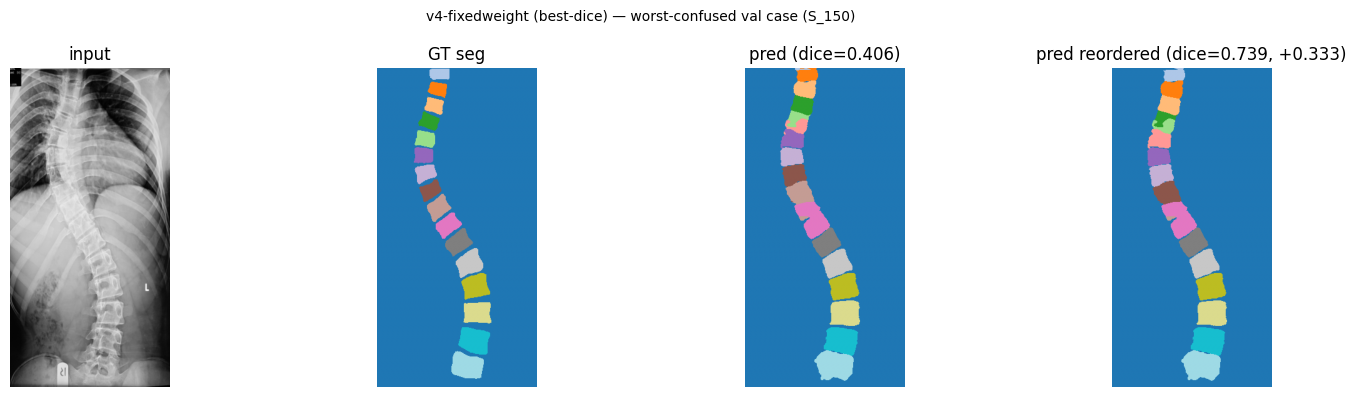

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


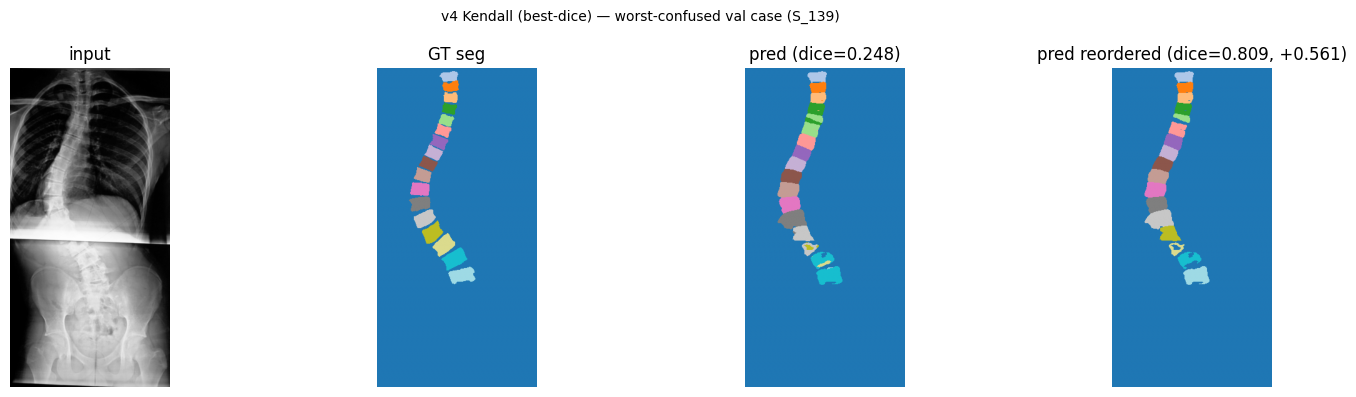

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


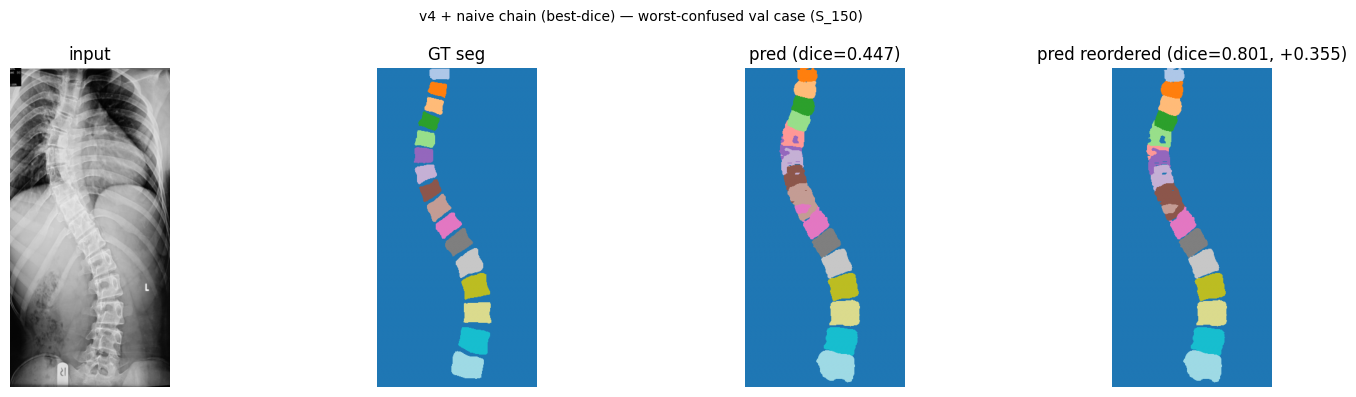

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


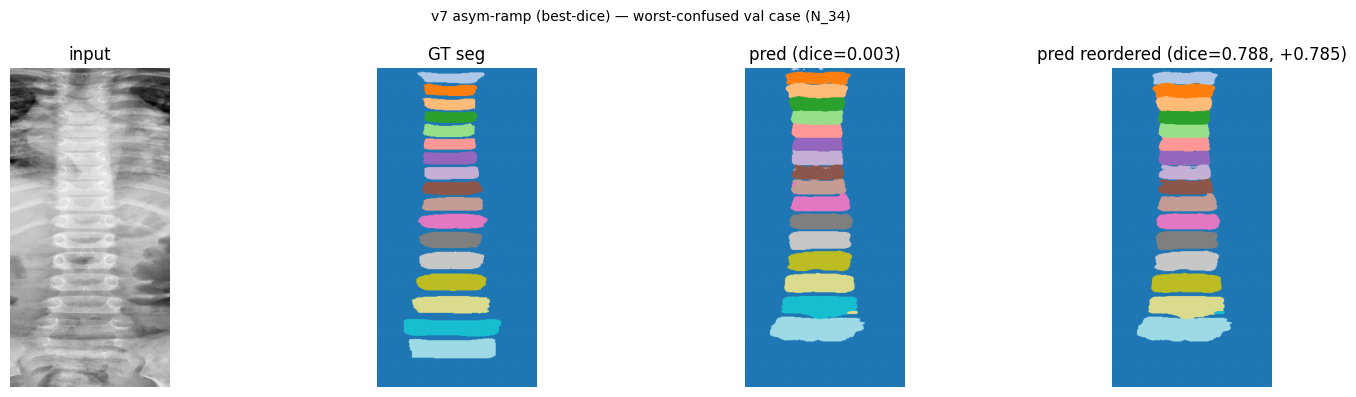

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


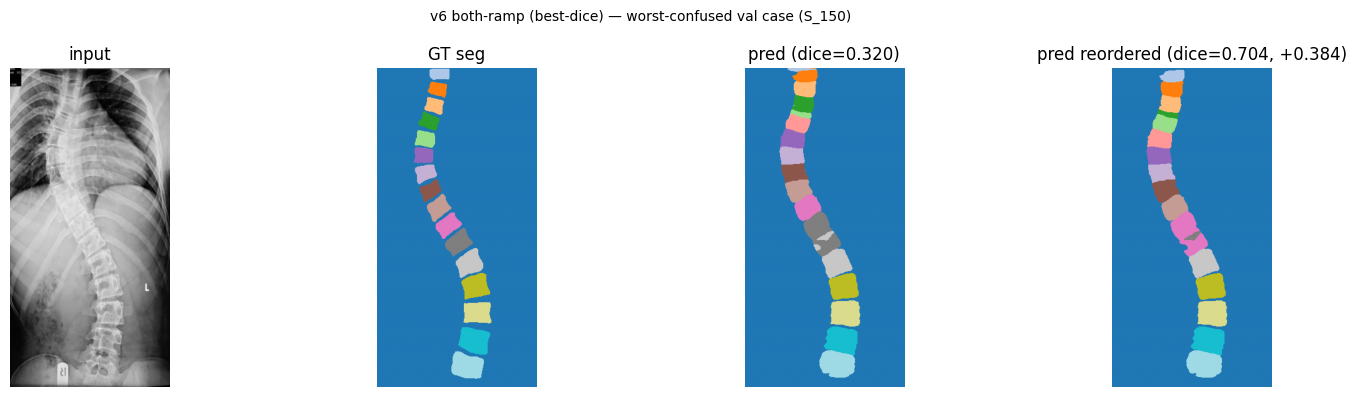

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


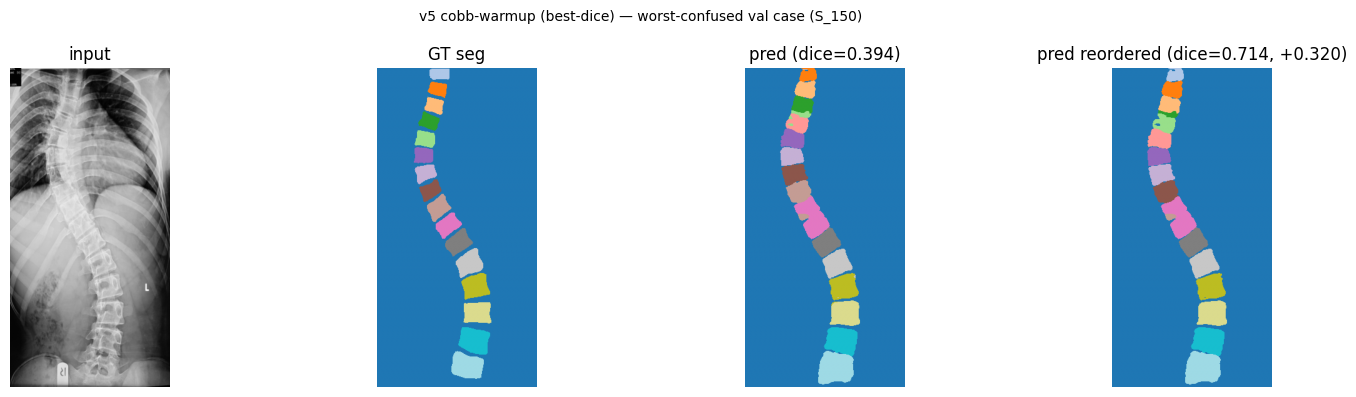

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


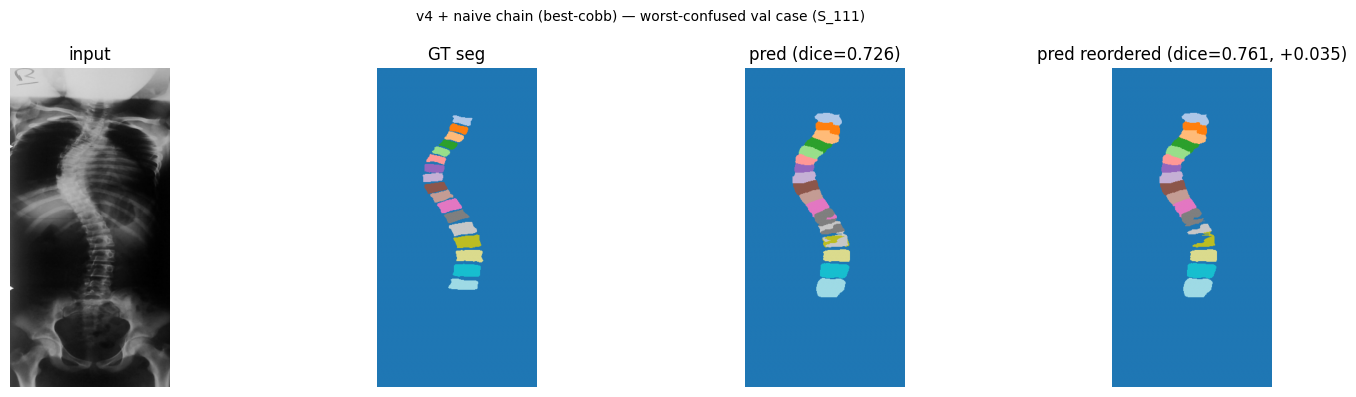

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


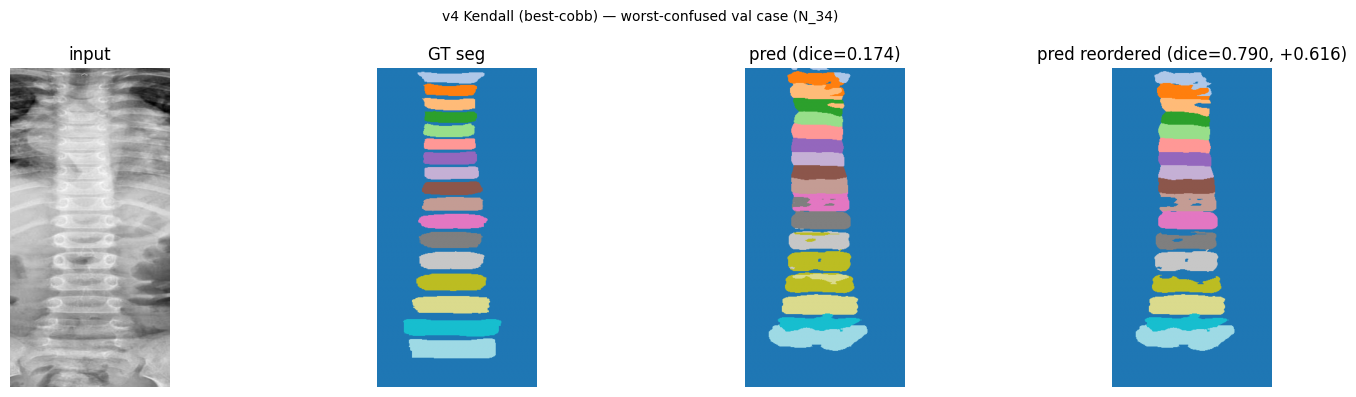

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


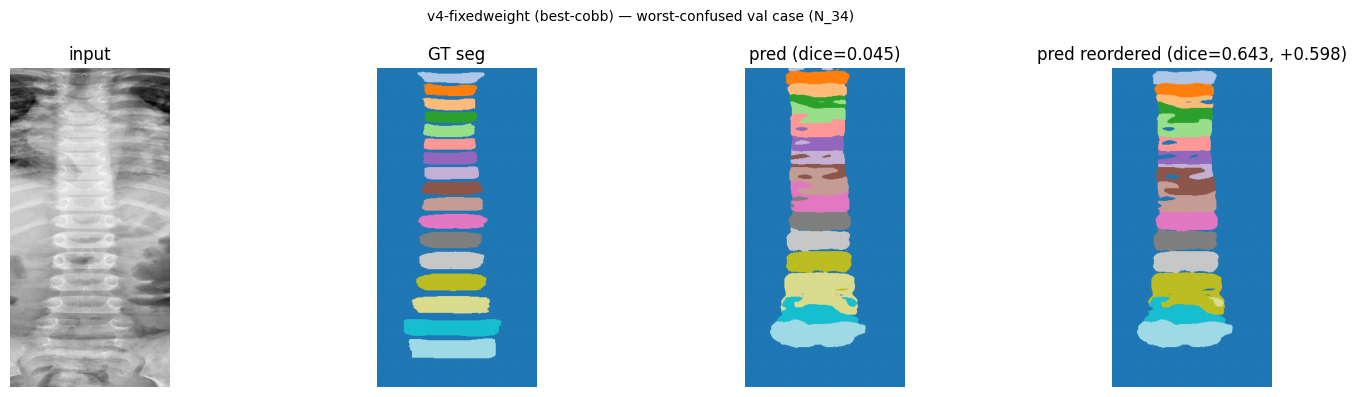

/tmp/ipykernel_56780/514432830.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_ROOT / rel, map_location='cpu')


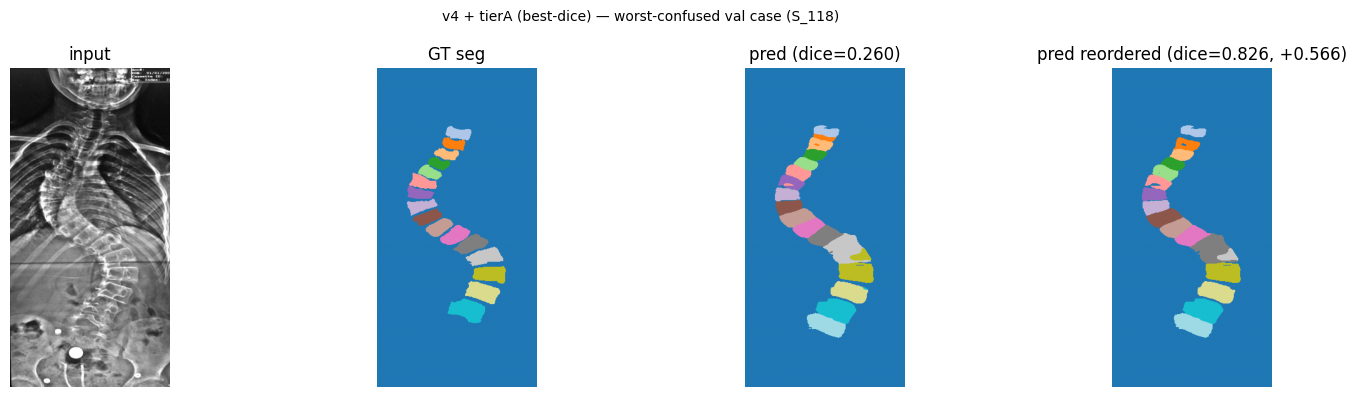

In [25]:
import matplotlib.colors as mcolors

for ckpt_name in summary["checkpoint"]:
    df = ALL[ALL["checkpoint"] == ckpt_name]
    worst = df.loc[df["dice_delta"].idxmax()]
    if worst["dice_delta"] < 0.005:
        continue  # nothing interesting to show
    # find the row in VAL_DF
    val_row = VAL_DF[VAL_DF["image_path"].str.contains(worst["image"], regex=False, na=False)]
    if len(val_row) == 0: continue
    val_row = val_row.iloc[0]
    case = preprocess_case(val_row)
    # need to reload checkpoint for this row
    rel = CHECKPOINT_DIRS[ckpt_name]
    state = torch.load(CKPT_ROOT / rel, map_location='cpu')
    sd = state["model"] if isinstance(state, dict) and "model" in state else state
    model_template.load_state_dict(sd); model_template.eval()
    with torch.no_grad():
        out = model_template(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu().numpy()
    seg_reord = reorder_vertebrae(seg_pred)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
    axes[1].imshow(case["seg"], cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES-1); axes[1].set_title("GT seg")
    axes[2].imshow(seg_pred, cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES-1); axes[2].set_title(f"pred (dice={worst['dice_pre']:.3f})")
    axes[3].imshow(seg_reord, cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES-1); axes[3].set_title(f"pred reordered (dice={worst['dice_post']:.3f}, +{worst['dice_delta']:.3f})")
    for ax in axes: ax.set_axis_off()
    fig.suptitle(f"{ckpt_name} — worst-confused val case ({worst['image']})", fontsize=10)
    plt.tight_layout(); plt.show()


## 8 · Conclusions

TODO after the run: read the §6 summary table and decide.

- **Mean `dice_delta` ≥ 0.05** across most checkpoints → class-confusion is the dominant gap. Commit to **Fix B** ([[Open_Questions]] Q-20 — training-time ordering loss). Expected to lift the v4 Dice ceiling AND make the kpt heatmaps more reliable.
- **Mean `dice_delta` 0.01–0.05** → modest improvement. Use reorder as a default inference step (one extra ~5ms call per sample); deprioritize Q-20.
- **Mean `dice_delta` < 0.01** → class confusion is NOT the gap; the model has deeper issues (boundary errors, missed vertebrae, extra fragments). Q-20 will not help; pivot to architectural rethink (Fix C).

Also check the **median number of predicted components**: if it's substantially less than 17, the model is missing vertebrae entirely (not class-swapping). Reorder cannot recover those — Fix B also won't help; that's a different problem.

**Cobb-from-seg MAE delta** matters too: even if dice barely improves, if `cobb_seg_mae_post` drops significantly, the spatial structure of the spine is being recovered in a way that helps Cobb derivation. Useful even if dice itself is marginal.

File the result as `[[2026-05-XX_vertebra_reorder_diagnostic]]` with the comparative table + decision (Q-20 commit / defer / kill).
